# 📘 Tutorial 1: Noisy and Replication-Aware BO Workflows

> This is the worked version of the notebook.
>
> All cells have been executed and include outputs, figures, and numerical results for reference.

In **Part 5**, we moved from standard Bayesian Optimisation workflows to more realistic experimental settings where candidate selection was shaped by **constraints, cost, budget limits, and human-guided decision rules**.

In particular, we saw that once BO is embedded inside a practical experimental workflow, the optimisation problem is no longer only about asking:

> **which candidate has the highest acquisition value?**

Instead, the workflow may also need to ask:

- whether a raw BO proposal corresponds to a feasible experiment,
- whether a repaired design is experimentally meaningful,
- whether the experiment is worth its cost,
- whether the remaining budget can support it,
- and whether practical decision rules should accept, delay, or veto the proposed candidate.

That established BO as more than a purely algorithmic loop.

It became a decision-making workflow.

In this tutorial, we take the next step:

> **what changes when the observations themselves are noisy, and the apparent best experiment may not be the truly best one?**

That is the focus of this notebook.

This is an important shift.

In many earlier BO examples, each evaluation was treated as if it returned the true objective value exactly. Once a candidate was evaluated, the optimiser could simply add that value to the dataset and move on.

But real experimental measurements are rarely perfectly deterministic.

The same experimental condition may give slightly different values if it is repeated, because of:

- instrumental noise,
- sample-to-sample variability,
- preparation differences,
- environmental fluctuations,
- stochastic reaction or material behaviour,
- or ordinary measurement uncertainty.

So instead of observing the latent objective value $f(x)$ directly, the optimiser observes a noisy measurement:

$$
y = f(x) + \varepsilon.
$$

That small change has large consequences.

The best observed value may not be the best true value.
A promising condition may only look promising because the noise happened to be favourable.
A repeated measurement may no longer be wasted effort.
And an acquisition function that relies on a fixed incumbent value may behave differently when the incumbent itself is uncertain.

So this tutorial is not mainly about changing the basic BO loop.

It is about learning how the interpretation of BO changes when **measurement noise** becomes part of the optimisation problem.

To make this concrete, the notebook uses a 1D synthetic **noisy minimisation** problem with multiple local minima. Because the true latent objective is known, we can compare:

- noisy observations,
- true latent function values,
- best noisy measurements,
- model-based recommendations,
- recommendation regret,
- and the number of unique locations explored.

Those diagnostics let us see directly when a method is being helped or misled by noise.

The notebook then compares three noisy BO workflows:

- a **standard LogEI** loop,
- a **replication-aware LogEI** loop,
- and a **qNEI** loop.

These workflows share the same noisy GP modelling setup and the same final recommendation rule, but they differ in how they respond to noisy observations.

The standard LogEI workflow acts as the baseline. It uses an improvement-based acquisition function and proposes a new candidate at every BO step.

The replication-aware LogEI workflow adds a practical experimental rule: if the current best model-based location looks promising but remains uncertain or under-confirmed, the workflow can choose to repeat that location instead of immediately moving elsewhere.

The qNEI workflow then introduces a more principled noisy-improvement acquisition function. Rather than comparing candidates against a single fixed incumbent value, qNEI integrates over posterior uncertainty in the latent values of already evaluated baseline points.

That makes qNEI especially relevant when the apparent best observation may not be trustworthy.

This notebook therefore asks several core questions:

- why the best noisy observation can be over-optimistic,
- why model-based recommendations are more meaningful than raw best measurements,
- when repeated measurements can be useful,
- how replication changes the exploration strategy,
- how qNEI differs mathematically from ordinary improvement-based acquisition,
- and how to compare noisy BO workflows across both a single run and multiple random trials.

This is also where the notebook connects directly to real experimental optimisation.

In a real campaign, researchers are often not asking only:

> **what is the best value we have measured so far?**

They are more often asking:

> **which condition do we actually believe is best after accounting for uncertainty?**

That is the noisy BO question.

---

**This tutorial is designed to shift perspective**
- from *“BO observes the objective value directly”*
- to *“BO must make decisions from noisy, uncertain measurements of the objective.”*

---

**The emphasis is on developing intuition for**
- why the best noisy observation may be misleading,
- why a noise-aware GP should not necessarily interpolate every data point,
- why minimisation problems are converted into BoTorch's maximisation convention using $-y$,
- why repeated measurements can be meaningful under noise,
- how replication trades exploration for confidence,
- and why qNEI is designed for noisy improvement rather than fixed-incumbent improvement.

---

**Key ideas explored include**
- defining a synthetic noisy minimisation problem,
- fitting a noise-aware `SingleTaskGP` with known observation variance,
- converting between the original minimisation scale and the BoTorch maximisation scale,
- using `LogExpectedImprovement` with a model-based incumbent,
- implementing a simple replication-aware LogEI workflow,
- using `qNoisyExpectedImprovement` with `X_baseline`,
- comparing best noisy observations against model-based recommendations,
- tracking unique evaluated locations and recommendation uncertainty,
- and running a small multi-trial comparison of final regret and exploration behaviour.

---

This tutorial serves as the bridge from:

- **budget-aware and human-guided BO workflows** in Part 5,
- to **more advanced BO settings where uncertainty, replication, and richer decision structures matter** in Part 6.

In other words:

- **Part 5** showed how BO changes when feasibility, cost, budget, and human decision rules shape the workflow,
- and **Part 6 Tutorial 1** now asks what happens when the data collected by that workflow are themselves noisy and uncertain.

---

**Recommended prerequisites**
- Completion of **Parts 1–5**
- Familiarity with Gaussian Process surrogates and acquisition functions in BoTorch
- Familiarity with the standard sequential BO loop
- Familiarity with LogEI or expected-improvement-style acquisition functions
- Basic understanding of noisy measurements, posterior uncertainty, and model-based recommendations

---

**Author**: Angze Li

**Last updated**: 2026-04-18

**Version**: v1.0

## 🔧 Setup

In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

from botorch.models import SingleTaskGP
from botorch.models.transforms import Normalize, Standardize
from botorch.fit import fit_gpytorch_mll
from botorch.optim import optimize_acqf
from botorch.utils.sampling import draw_sobol_samples
from botorch.sampling.normal import SobolQMCNormalSampler
from botorch.acquisition.analytic import LogExpectedImprovement
from botorch.acquisition.monte_carlo import qNoisyExpectedImprovement

from gpytorch.mlls import ExactMarginalLogLikelihood

warnings.filterwarnings("ignore")

torch.set_default_dtype(torch.double)


def set_seed(seed=0):
    torch.manual_seed(seed)
    np.random.seed(seed)


def style_ax(ax):
    for spine in ax.spines.values():
        spine.set_linewidth(1.8)
    ax.tick_params(axis="both", labelsize=14)
    for t in ax.get_xticklabels() + ax.get_yticklabels():
        t.set_fontweight("bold")

## 1. Defining a noisy minimisation problem

We start by defining the 1D synthetic objective function used throughout this tutorial.

Unlike the earlier BO examples, this notebook treats the problem as a **minimisation** task:

$$
\min_x f(x).
$$

This means that smaller objective values are better. In the plots that follow, the optimiser is trying to locate the lowest region of the latent objective, rather than the highest peak.

---

### Why this objective is useful

The function `objective_1d(x)` represents the true latent objective.

In a real BO problem, this function would be unknown. We would only observe experimental measurements from it.

Here, because this is a synthetic tutorial problem, we can evaluate the true function directly and use it for diagnostics.

The objective is deliberately structured to be non-trivial. It contains:

- several Gaussian-like wells,
- oscillatory terms,
- a mild quadratic trend,
- and a smooth nonlinear background contribution.

This creates multiple attractive regions rather than one obvious minimum.

That is important for the tutorial, because noisy BO is most interesting when the optimiser has to decide whether a good-looking region is truly global or merely a convincing local basin.

---

### Latent objective versus noisy observation

The helper function `latent_objective(X)` ensures that inputs have the correct tensor shape before being passed into `objective_1d(x)`.

The function `observe_noisy(X)` then defines the noisy observation process:

$$
y = f(x) + \varepsilon,
$$

where $\varepsilon$ is a random measurement-noise term.

In this notebook, we set the observation noise standard deviation to

$$
\sigma_{\text{noise}} = 0.12.
$$

This means that two evaluations at the same $x$ value can return different observed values.

That is the key reason replication becomes meaningful: repeating a measurement can help determine whether a promising observation is genuinely good or merely a lucky noisy draw.

---

### Search domain and true optimum

The search domain is defined as

$$
x \in [-3, 3].
$$

We then construct a dense grid over this interval and evaluate the true latent objective on that grid.

Because the objective is synthetic, we can also identify the approximate true minimiser directly using `torch.argmin` over the dense grid.

---

### Why this matters for noisy BO

This objective contains more than one plausible low-value region.

That makes it possible for a BO method to become attracted to a strong local basin, especially if early noisy observations make that basin look more promising than it truly is.

So the central question is not only:

> where did we observe the lowest noisy value?

but also:

> which region does the model believe is genuinely best after accounting for noise and uncertainty?

This distinction will be used throughout the notebook when comparing LogEI, replication-aware LogEI, and qNEI.

---

### Key takeaway

This cell defines the noisy minimisation problem for the tutorial.

The optimiser does not directly observe the latent function $f(x)$. It observes noisy measurements $y = f(x) + \varepsilon$.

That difference is what makes noisy BO fundamentally different from the noiseless setting: the best measured value may not be the best true value, and repeated measurements may provide useful information rather than being redundant.

In [2]:
def objective_1d(x):
    return (
            -0.48 * torch.exp(-0.5 * ((x + 1.9) / 0.55) ** 2)
            - 0.95 * torch.exp(-0.5 * ((x + 0.35) / 0.22) ** 2)
            - 1.05 * torch.exp(-0.5 * ((x - 1.75) / 0.30) ** 2)
            + 0.10 * torch.sin(2.8 * x)
            + 0.06 * torch.sin(6.5 * x + 0.4)
            + 0.035 * torch.cos(11.0 * x)
            + 0.24 * torch.tan(0.3 * x)
            + 0.025 * (x - 0.4) ** 2
            + 0.16
    )

def latent_objective(X):
    if X.ndim == 1:
        X = X.unsqueeze(-1)
    return objective_1d(X)

seed = 7
set_seed(seed)

bounds = torch.tensor([[-3.0], [3.0]], dtype=torch.double)
noise_std = 0.12

def observe_noisy(X, noise_std=noise_std):
    true_y = latent_objective(X)
    noise = noise_std * torch.randn_like(true_y)
    return true_y + noise

grid_X = torch.linspace(bounds[0, 0], bounds[1, 0], 600).unsqueeze(-1)
grid_Y_true = latent_objective(grid_X)

true_best_idx = torch.argmin(grid_Y_true)
true_best_x = grid_X[true_best_idx]
true_best_y = grid_Y_true[true_best_idx]

print("True minimiser x:", float(true_best_x))
print("True minimum latent value:", float(true_best_y))
print("Observation noise std:", noise_std)

True minimiser x: -0.3455759599332221
True minimum latent value: -0.9774750898844072
Observation noise std: 0.12


## 2. Initial noisy observations

We now generate the initial noisy dataset used to start the BO loop.

Up to this point, we have defined the latent objective function and the noisy observation process. However, BO does not begin with full knowledge of the objective. It begins with a small set of initial evaluations.

That is the purpose of this cell.

---

### Why an initial dataset is needed

Bayesian optimisation is a sequential model-based optimisation method.
Before the first acquisition function can be optimised, the surrogate model needs some initial data.

Here, the initial input locations are generated using Sobol sampling over the search interval. This provides a small, reasonably space-filling set of points before any model-based decision rule is introduced.

This is important because the initial data determine the first GP posterior, and therefore influence the first LogEI candidate proposed later.

---

### What is recorded in the initial dataset

For each initial point, we store four quantities:

- `x`: the sampled input location,
- `latent_f(x)`: the true latent objective value,
- `noisy_y`: the noisy value actually observed by the optimiser,
- `known_noise_var`: the assumed observation noise variance, $\sigma_{\text{noise}}^2$.

The distinction between `latent_f(x)` and `noisy_y` is central to this notebook.

In the synthetic setting, we can inspect both the true latent value

$$
f(x)
$$

and the noisy measurement

$$
y = f(x) + \varepsilon.
$$

In a real experiment, only the noisy measurement $y$ would be available.

---

### Why the best noisy observation can be misleading

The printed diagnostics compare two quantities:

- the lowest noisy observation in the initial dataset,
- and the lowest true latent value among the same sampled locations.

For a minimisation problem, a noisy observation may look artificially good if the noise happens to push it downward.

So the lowest observed `noisy_y` is not necessarily the best true condition.
It may simply be a lucky measurement.

This is one of the main reasons noisy BO is more subtle than noiseless BO.
The optimiser must decide whether a low-looking point is genuinely promising or whether it should be treated with caution because of observation noise.

---

### What the figure shows

The figure visualises the same idea.

It shows:

- the true latent objective as a smooth curve,
- the noisy observations as circular markers,
- the true latent values at the sampled inputs as cross markers,
- and the true minimiser as a dashed vertical line.

The vertical difference between a circular marker and the corresponding cross marker is the observation noise for that evaluation.

This makes the key problem visible:

> BO does not observe the latent objective directly; it only observes noisy measurements of it.

---

### Why this matters for the rest of the notebook

This initial dataset will be used to fit the first noise-aware GP surrogate.

From there, the notebook compares three strategies:

- ordinary LogEI,
- replication-aware LogEI,
- and qNEI.

The reason these strategies differ is that they respond differently to noisy observations.

Ordinary LogEI asks where improvement is expected next.
Replication-aware LogEI adds a simple rule for confirming promising but uncertain locations.
qNEI treats noisy improvement more directly by accounting for uncertainty in the current best latent value.

So this cell establishes the core empirical situation for the rest of the tutorial:

> the optimiser starts with limited data, and those data are noisy.

---

### Key takeaway

This cell creates the initial noisy observations for the BO loop and makes the distinction between latent objective values and observed noisy measurements explicit.

That distinction is what motivates the rest of the notebook: in noisy BO, the apparent best observation may not be trustworthy, so the optimisation strategy must reason not only about where the objective might be low, but also about how much confidence we should place in the measurements already collected.

,x,latent_f(x),noisy_y,known_noise_var
0,-1.803161,-0.164846,-0.150051,0.0144
1,-1.974407,-0.293433,-0.215894,0.0144
2,1.496142,-0.579282,-0.592441,0.0144
3,-1.894117,-0.236182,-0.180147,0.0144
4,0.303135,0.252887,0.350728,0.0144
5,1.593833,-0.743405,-0.815678,0.0144
6,-0.823996,-0.075803,-0.108075,0.0144
7,2.896669,0.749496,0.706749,0.0144


Initial best noisy observation: -0.8156781366122974
Initial best latent value among sampled points: -0.7434052741406928


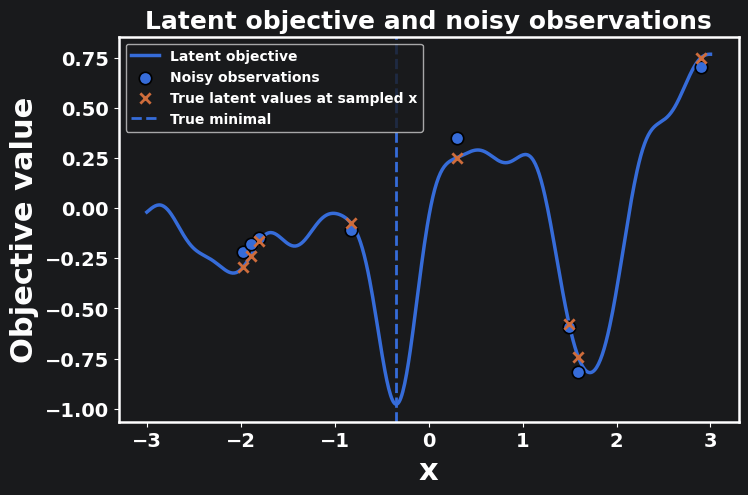

In [3]:
set_seed(seed)

n_init = 8

train_X_init = draw_sobol_samples(bounds=bounds, n=1, q=n_init).squeeze(0)
train_Y_init = observe_noisy(train_X_init, noise_std=noise_std)
train_Yvar_init = torch.full_like(train_Y_init, noise_std ** 2)

init_df = pd.DataFrame({
    "x": train_X_init.view(-1).detach().cpu().numpy(),
    "latent_f(x)": latent_objective(train_X_init).view(-1).detach().cpu().numpy(),
    "noisy_y": train_Y_init.view(-1).detach().cpu().numpy(),
    "known_noise_var": train_Yvar_init.view(-1).detach().cpu().numpy(),
})

display(init_df)

print("Initial best noisy observation:", float(torch.min(train_Y_init)))
print("Initial best latent value among sampled points:", float(torch.min(latent_objective(train_X_init))))

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(grid_X.view(-1), grid_Y_true.view(-1), lw=2.5, label="Latent objective")

ax.scatter(train_X_init.view(-1),
           train_Y_init.view(-1),
           s=80,
           edgecolor="black",
           lw=1.2,
           zorder=3,
           label="Noisy observations")

ax.scatter(train_X_init.view(-1),
           latent_objective(train_X_init).view(-1),
           s=55,
           marker="x",
           lw=2.0,
           zorder=4,
           label="True latent values at sampled x")

ax.axvline(float(true_best_x), linestyle="--", linewidth=2.0, label="True minimal")

ax.set_title("Latent objective and noisy observations", fontsize=18, fontweight="bold")
ax.set_xlabel("x", fontsize=22, fontweight="bold")
ax.set_ylabel("Objective value", fontsize=22, fontweight="bold")
ax.legend(prop={"size": 10, "weight": "bold"})
style_ax(ax)
plt.show()

## 3. Fitting a noise-aware GP surrogate

We now fit the first Gaussian Process surrogate to the initial noisy observations.

This is the first point where the notebook moves from raw data to a probabilistic model of the unknown objective.

---

### Why the target is transformed

The original problem is a **minimisation** problem:

$$
\min_x f(x).
$$

However, BoTorch acquisition functions are usually written using a **maximisation** convention.

To make the minimisation problem compatible with this convention, we fit the GP to the transformed target

$$
-y.
$$

This means:

- low values of $y$ are good on the original objective scale,
- high values of $-y$ are good on the BoTorch acquisition scale.

So the model internally works with a maximisation problem, while the plots are converted back to the original minimisation scale.

---

### Why the GP is noise-aware

The function `fit_noisy_gp(...)` also passes an explicit observation noise variance to the GP:

$$
\sigma_{\text{noise}}^2.
$$

This tells the model that the observed values are noisy measurements rather than exact function values.

As a result, the posterior mean does not need to pass exactly through every observed data point. This is important in noisy BO, because forcing the model to interpolate noisy measurements would make it over-trust random experimental variation.

---

### Returning to the original objective scale

The helper function `posterior_on_grid_original_scale(...)` evaluates the GP posterior on the dense grid.

Since the GP was fit to $-y$, the posterior mean is first obtained on the BoTorch scale and then converted back:

$$
\mu_{\text{original}}(x) = -\mu_{\text{BO}}(x).
$$

The posterior standard deviation is kept unchanged, because multiplying the target by $-1$ changes the sign of the mean but not the uncertainty magnitude.

---

### What the figure shows

The figure compares:

- the true latent objective,
- the GP posterior mean,
- the posterior uncertainty band,
- the noisy initial observations,
- and the true minimiser.

The key point is that the GP is not only giving a best estimate of the objective. It is also quantifying uncertainty about that estimate.

This uncertainty is what later acquisition functions will use to decide where to evaluate next.

---

### Key takeaway

This cell constructs the first **noise-aware GP surrogate** for the BO loop.

Because the model knows that observations are noisy, it treats the data as uncertain evidence about the latent objective rather than exact function values.

That distinction is essential for the rest of the tutorial, where LogEI, replication-aware LogEI, and qNEI make different decisions based on how they interpret noisy observations and posterior uncertainty.

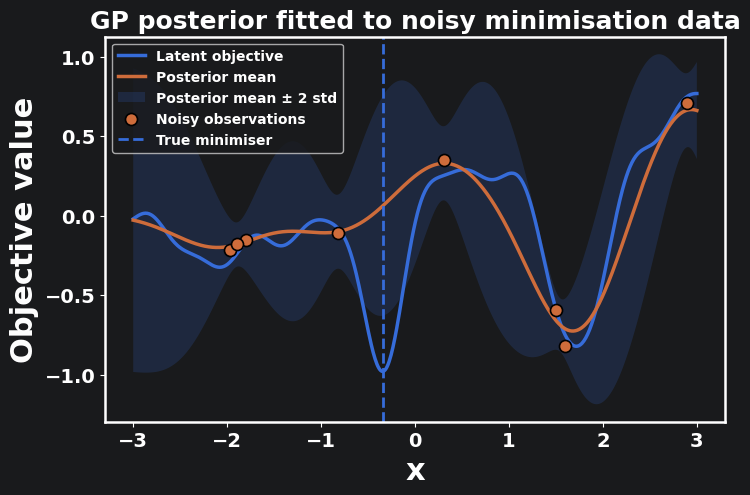

In [4]:
def fit_noisy_gp(train_X, train_Y, noise_std=noise_std):
    train_Y_bo = -train_Y
    train_Yvar = torch.full_like(train_Y_bo, noise_std ** 2)

    gp = SingleTaskGP(
        train_X=train_X,
        train_Y=train_Y_bo,
        train_Yvar=train_Yvar,
        input_transform=Normalize(d=train_X.shape[-1]),
        outcome_transform=Standardize(m=1),
    )

    mll = ExactMarginalLogLikelihood(gp.likelihood, gp)
    fit_gpytorch_mll(mll)
    gp.eval()

    return gp


def posterior_on_grid_original_scale(model, grid_X):
    with torch.no_grad():
        posterior = model.posterior(grid_X)
        mean_bo = posterior.mean.squeeze(-1)
        std = posterior.variance.sqrt().squeeze(-1)

    mean_original = -mean_bo
    return mean_original, std

gp_init = fit_noisy_gp(train_X_init, train_Y_init, noise_std=noise_std)

mean_original, std = posterior_on_grid_original_scale(gp_init, grid_X)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(grid_X.view(-1), grid_Y_true.view(-1), lw=2.5, label="Latent objective")
ax.plot(grid_X.view(-1), mean_original.view(-1), lw=2.5, label="Posterior mean")

ax.fill_between(
    grid_X.view(-1).detach().cpu().numpy(),
    (mean_original - 2 * std).view(-1).detach().cpu().numpy(),
    (mean_original + 2 * std).view(-1).detach().cpu().numpy(),
    alpha=0.18,
    label="Posterior mean ± 2 std"
)

ax.scatter(
    train_X_init.view(-1),
    train_Y_init.view(-1),
    s=75,
    edgecolor="black",
    lw=1.2,
    zorder=3,
    label="Noisy observations"
)

ax.axvline(float(true_best_x), linestyle="--", lw=2.0, label="True minimiser")

ax.set_title("GP posterior fitted to noisy minimisation data", fontsize=18, fontweight="bold")
ax.set_xlabel("x", fontsize=22, fontweight="bold")
ax.set_ylabel("Objective value", fontsize=22, fontweight="bold")
ax.legend(prop={"size": 10, "weight": "bold"})
style_ax(ax)
plt.show()

## 4. Shared helper functions for noisy BO workflows

Before running the different BO strategies, we define a small set of helper functions that will be reused throughout the rest of the notebook.

These functions do not run a full BO loop by themselves.
Instead, they provide the shared machinery needed to:

- define the LogEI incumbent,
- propose a new LogEI candidate,
- extract the model’s current recommendation,
- count how many unique locations have been evaluated,
- and record useful diagnostics at each BO step.

---

### Model-based incumbent for LogEI

The function `model_based_best_f(...)` defines the incumbent value used by `LogExpectedImprovement`.

Because the original problem is a minimisation problem, the GP is fit to the transformed target

$$
-y.
$$

Therefore, on the BoTorch scale, larger values are better.

Instead of using the raw best noisy observation directly, this function evaluates the GP posterior mean at the already observed inputs and takes the largest posterior mean on the BO scale.

This is important in noisy BO.

A raw noisy observation may look artificially good simply because of favourable noise.
Using a model-based incumbent is a more stable way to define the current reference point for LogEI.

---

### Proposing a LogEI candidate

The function `propose_logei_candidate(...)` builds a `LogExpectedImprovement` acquisition function and optimises it using `optimize_acqf`.

It returns:

- the proposed candidate point,
- the acquisition value at that candidate,
- and the model-based incumbent `best_f`.

This function will be used by the ordinary LogEI workflow, and also by the replication-aware LogEI workflow whenever that workflow decides to evaluate a new point rather than repeat an existing one.

---

### Model-based recommendation

The function `current_recommendation_from_model(...)` asks:

> according to the current GP posterior, which point looks best?

Since the notebook is working on the original minimisation scale for interpretation, the recommendation is chosen as the grid point with the lowest posterior mean.

It also returns:

- the true latent value at that recommended point,
- and the posterior standard deviation there.

The true latent value is only available because this is a synthetic tutorial problem. In a real experiment, this diagnostic would not be directly observable.

---

### Counting unique evaluated locations

The function `n_unique_1d(...)` counts how many distinct input locations have been evaluated.

This becomes important once replication is allowed.

For ordinary BO, the number of observations and the number of unique locations are usually almost the same.
For replication-aware BO, these can differ because the same location may be measured more than once.

---

### Recording the state of a BO run

Finally, `summarise_state(...)` collects the information needed to analyse each BO step.

It records:

- the current training data,
- the proposed next point,
- the new noisy observation,
- the action taken,
- the best noisy observation so far,
- the best latent value among sampled points,
- the model-based recommendation,
- the uncertainty at that recommendation,
- the total number of observations,
- and the number of unique evaluated locations.

This is what makes the later diagnostic plots possible.

---

### Key takeaway

This cell defines the shared bookkeeping and decision-support functions used by all three BO workflows:

- LogEI,
- replication-aware LogEI,
- and qNEI.

The main purpose is to make the later comparisons fair and interpretable: all strategies will be evaluated using the same recommendation rule, the same summary statistics, and the same diagnostic structure.

In [5]:
def model_based_best_f(model, train_X):
    with torch.no_grad():
        posterior_train = model.posterior(train_X)
        mean_train_bo = posterior_train.mean.squeeze(-1)

    return mean_train_bo.max().item()

def propose_logei_candidate(
        model,
        train_X,
        bounds,
        num_restarts=10,
        raw_samples=128,
):
    best_f = model_based_best_f(model, train_X)
    acq = LogExpectedImprovement(model=model, best_f=best_f)

    candidate, acq_value = optimize_acqf(
        acq_function=acq,
        bounds=bounds,
        q=1,
        num_restarts=num_restarts,
        raw_samples=raw_samples,
    )

    return candidate.detach(), float(acq_value), best_f

def current_recommendation_from_model(model, grid_X):
    mean_original, std = posterior_on_grid_original_scale(model, grid_X)
    idx = torch.argmin(mean_original)

    x_rec = grid_X[idx].reshape(1, -1)
    y_rec_latent = latent_objective(x_rec)
    std_rec = std[idx]

    return x_rec, y_rec_latent, std_rec


def n_unique_1d(train_X, decimals=4):
    return len(torch.unique(torch.round(train_X.view(-1), decimals=decimals)))


def summarise_state(step, train_X, train_Y, model, grid_X, x_next=None, y_next=None, action=None):
    x_rec, y_rec_latent, std_rec = current_recommendation_from_model(model, grid_X)

    return {
        "step": step,
        "train_X": train_X.clone(),
        "train_Y": train_Y.clone(),
        "x_next": None if x_next is None else x_next.clone(),
        "y_next": None if y_next is None else y_next.clone(),
        "action": action,
        "best_noisy_observed": float(torch.min(train_Y)),
        "best_latent_sampled": float(torch.min(latent_objective(train_X))),
        "recommendation_x": float(x_rec),
        "recommendation_latent_y": float(y_rec_latent),
        "recommendation_std": float(std_rec),
        "n_observations": train_X.shape[0],
        "n_unique": n_unique_1d(train_X),
    }

## 5. Standard noisy BO with LogEI

We now define the first full BO workflow: ordinary LogEI under noisy observations.

This function runs a sequential BO loop in which each step follows the same basic structure:

1. fit a noise-aware GP to the current data,
2. construct a LogEI acquisition function,
3. propose a new candidate by optimising LogEI,
4. evaluate the candidate with noisy observations,
5. store diagnostics,
6. update the dataset.

---

### What this workflow represents

This is the baseline strategy for the notebook.

At every step, the policy chooses a **new LogEI candidate**. It does not explicitly decide to repeat earlier measurements.

So this workflow answers the question:

> what happens if we run an ordinary improvement-based BO loop when the observations are noisy?

This makes it a useful comparison point for the later replication-aware and qNEI workflows.

---

### Why LogEI is used

`LogExpectedImprovement` is an improvement-based acquisition function.

It asks where the model expects improvement relative to the current incumbent value. In this notebook, that incumbent is defined using the model posterior rather than the raw best noisy observation.

This matters because the raw best noisy observation may be artificially low in a minimisation problem.

So the LogEI policy is still improvement-based, but it avoids directly trusting the most extreme noisy measurement.

---

### What is stored in `history`

At each step, the function records a dictionary containing the state of the BO run.

This includes:

- the current training data,
- the next candidate,
- the noisy observation at that candidate,
- the action label `"new_logei"`,
- the best noisy observation so far,
- the best latent value sampled so far,
- the model-based recommendation,
- the uncertainty at that recommendation,
- the number of observations,
- and the number of unique evaluated locations.

This bookkeeping is important because later we will compare different BO policies not only by their final result, but also by how they used the evaluation budget.

---

### What happens at the end

After the final BO step, the function fits one last GP model to the full dataset and appends a final summary state.

The function then returns:

- the full history of the run,
- the final input data,
- the final noisy observations,
- and the final fitted model.

---

### Key takeaway

This function implements the standard noisy LogEI baseline.

It always uses the acquisition function to propose a new point, so it focuses on improvement-driven exploration and exploitation, but does not explicitly spend evaluations on confirming previous noisy observations.

In [6]:
def run_logei_noisy_bo_loop(
        train_X_init,
        train_Y_init,
        n_steps,
        noise_std=noise_std,
        num_restarts=10,
        raw_samples=128,
):
    train_X = train_X_init.clone()
    train_Y = train_Y_init.clone()

    history = []

    for step in range(n_steps):
        model = fit_noisy_gp(train_X, train_Y, noise_std=noise_std)

        candidate, acq_value, best_f = propose_logei_candidate(
            model=model,
            train_X=train_X,
            bounds=bounds,
            num_restarts=num_restarts,
            raw_samples=raw_samples,
        )

        y_new = observe_noisy(candidate, noise_std=noise_std)

        state = summarise_state(
            step=step,
            train_X=train_X,
            train_Y=train_Y,
            model=model,
            grid_X=grid_X,
            x_next=candidate,
            y_next=y_new,
            action="new_logei",
        )
        state["candidate_logei_value"] = acq_value
        state["best_f_bo_scale"] = best_f
        history.append(state)

        train_X = torch.cat([train_X, candidate], dim=0)
        train_Y = torch.cat([train_Y, y_new], dim=0)

    final_model = fit_noisy_gp(train_X, train_Y, noise_std=noise_std)
    history.append(
        summarise_state(
            step=n_steps,
            train_X=train_X,
            train_Y=train_Y,
            model=final_model,
            grid_X=grid_X,
            action="final",
        )
    )

    return {
        "history": history,
        "train_X_final": train_X,
        "train_Y_final": train_Y,
        "model_final": final_model,
    }

## 6. Replication-aware noisy BO with LogEI

We now define a modified LogEI workflow that can choose between two possible actions at each BO step:

- evaluate a **new** point proposed by LogEI,
- or **replicate** a previously evaluated point that currently looks promising but uncertain.

This is the first workflow in the notebook that explicitly treats replication as a decision.

---

### Why replication is introduced

In ordinary BO, each evaluation usually goes to a new candidate point.

That makes sense when observations are effectively noiseless, because evaluating the same point again would provide no new information.

However, in noisy experimental settings, repeated measurements can be valuable.

If a point appears promising, but its observed value may have been affected by noise, then repeating that point can help answer a different question:

> is this point genuinely good, or did it only look good because of a lucky noisy observation?

So replication is not wasted effort.
It is a way of reducing uncertainty about a potentially important condition.

---

### How the replication decision is made

At each step, the function first fits a noise-aware GP to the current data.

It then looks at the already evaluated locations and identifies the one with the largest posterior mean on the BoTorch scale.

Because the model is fit to $-y$, this corresponds to the currently best model-estimated point for the original minimisation problem.

The function then checks two things:

1. **How many times has this point already been measured?**

   If the point has been measured fewer than `min_repeats_at_best` times, it may still need confirmation.

2. **How uncertain is the model at this point?**

   If the posterior standard deviation is larger than `replicate_threshold`, the point is still considered uncertain.

Together, these checks define two Boolean conditions:

- `should_confirm_best`
- `still_uncertain`

If either condition is satisfied, and the point has not exceeded `max_repeats_per_point`, the workflow replicates the current best model-based location.

Otherwise, it proposes a new point using LogEI.

---

### What the action labels mean

Each step is labelled as either:

- `"replicate"`
  the workflow repeats the current best model-based location,

- `"new_logei"`
  the workflow evaluates a new point proposed by LogEI.

These action labels are stored in `history`, so later diagnostics can show how often the workflow spent evaluations on replication rather than exploration.

---

### Why this is only a heuristic

This replication rule is deliberately simple.

It is not meant to be the mathematically optimal way to decide between replication and exploration.

Instead, it represents a practical experimental logic:

> if a point looks promising but has not been confirmed enough, or remains uncertain, repeat it before moving on.

That makes the workflow easy to interpret and useful as a teaching example.

Later, qNEI will provide a more principled noisy-improvement strategy.

---

### Key takeaway

This function implements a **replication-aware LogEI workflow**.

It keeps the same improvement-based logic as ordinary LogEI, but adds an explicit confirmation rule for promising noisy points.

This allows the notebook to compare two different uses of the same evaluation budget:

- ordinary LogEI spends almost every step on new locations,
- replication-aware LogEI spends some steps confirming existing promising locations.

That is the central exploration–replication trade-off studied in this tutorial.

In [7]:
def run_replication_aware_logei_bo_loop(
        train_X_init,
        train_Y_init,
        n_steps,
        noise_std=noise_std,
        replicate_threshold=0.10,
        min_repeats_at_best=3,
        max_repeats_per_point=5,
        num_restarts=10,
        raw_samples=128,
        repeat_atol=1e-4,
):
    train_X = train_X_init.clone()
    train_Y = train_Y_init.clone()

    history = []

    for step in range(n_steps):
        model = fit_noisy_gp(train_X, train_Y, noise_std=noise_std)

        with torch.no_grad():
            posterior_train = model.posterior(train_X)
            mean_train_bo = posterior_train.mean.squeeze(-1)
            std_train = posterior_train.variance.sqrt().squeeze(-1)

        best_idx = torch.argmax(mean_train_bo)
        x_best_observed = train_X[best_idx].reshape(1, -1)
        std_best_observed = std_train[best_idx]

        n_repeats = int(
            torch.isclose(
                train_X.view(-1),
                x_best_observed.view(-1),
                atol=repeat_atol,
            ).sum().item()
        )

        should_confirm_best = (
            n_repeats < min_repeats_at_best
            and float(std_best_observed) > 0.5 * replicate_threshold
        )
        still_uncertain = float(std_best_observed) > replicate_threshold

        if (should_confirm_best or still_uncertain) and n_repeats < max_repeats_per_point:
            candidate = x_best_observed
            decision_info = {
                "action": "replicate",
                "std_at_replicated_point": float(std_best_observed),
                "n_repeats_before": n_repeats,
                "min_repeats_at_best": min_repeats_at_best,
            }
        else:
            candidate, acq_value, best_f = propose_logei_candidate(
                model=model,
                train_X=train_X,
                bounds=bounds,
                num_restarts=num_restarts,
                raw_samples=raw_samples,
            )
            decision_info = {
                "action": "new_logei",
                "candidate_logei_value": acq_value,
                "best_f_bo_scale": best_f,
            }

        y_new = observe_noisy(candidate, noise_std=noise_std)

        state = summarise_state(
            step=step,
            train_X=train_X,
            train_Y=train_Y,
            model=model,
            grid_X=grid_X,
            x_next=candidate,
            y_next=y_new,
            action=decision_info["action"],
        )
        state.update(decision_info)
        history.append(state)

        train_X = torch.cat([train_X, candidate], dim=0)
        train_Y = torch.cat([train_Y, y_new], dim=0)

    final_model = fit_noisy_gp(train_X, train_Y, noise_std=noise_std)
    history.append(
        summarise_state(
            step=n_steps,
            train_X=train_X,
            train_Y=train_Y,
            model=final_model,
            grid_X=grid_X,
            action="final",
        )
    )

    return {
        "history": history,
        "train_X_final": train_X,
        "train_Y_final": train_Y,
        "model_final": final_model,
    }

## 7. Noisy BO with qNEI

We now define the third BO workflow: noisy Bayesian optimisation using `qNoisyExpectedImprovement`, or **qNEI**.

This is the most explicitly noise-aware acquisition strategy in the notebook.

The previous two workflows used LogEI together with a model-based incumbent. That already avoids directly trusting the raw best noisy observation. However, LogEI still depends on a single reference value, `best_f`, which must be chosen before the acquisition function is evaluated.

qNEI takes a different approach.

Instead of treating the current best value as fixed, qNEI treats the latent function values at the already observed points as uncertain quantities under the GP posterior.

That is exactly what we want in noisy BO.

---

### The problem with ordinary expected improvement under noise

In a noiseless setting, expected improvement compares a candidate point $x$ against the best observed value so far.

For a maximisation problem, the usual improvement is conceptually

$$
I(x) = \max(f(x) - f_{\text{best}}, 0).
$$

The expected improvement is then

$$
\operatorname{EI}(x) = \mathbb{E}[\max(f(x) - f_{\text{best}}, 0)].
$$

This works naturally when $f_{\text{best}}$ is known exactly.

But in noisy BO, we do not observe $f(x_i)$ directly. We observe

$$
y_i = f(x_i) + \varepsilon_i.
$$

So the best noisy observation may not be the best latent function value. A point may look excellent simply because the noise happened to be favourable.

This makes the reference value $f_{\text{best}}$ uncertain.

---

### What qNEI changes

qNEI avoids fixing a single observed best value.

Instead, it uses the GP posterior to sample possible latent function values at both:

- the previously evaluated points, $X_{\text{baseline}}$,
- and the new candidate point or batch, $X$.

For a maximisation problem, qNEI estimates improvement of the form

$$
\operatorname{qNEI}(X)
= \mathbb{E}\left[
\max\left(
\max f(X) - \max f(X_{\text{baseline}}),\, 0
\right)
\right].
$$

The expectation is taken over the joint GP posterior distribution of the latent function values.

This means qNEI does not compare the candidate against the raw best noisy observation. It compares the candidate against the uncertain posterior distribution of the best latent value among the already evaluated points.

That is the key mathematical difference.

---

### How this applies to our minimisation problem

Our original objective is a minimisation problem:

$$
\min_x f(x).
$$

As before, the GP is fit to the transformed target

$$
-y.
$$

So qNEI is still used in BoTorch's maximisation convention. It is searching for improvement in $-f(x)$, which is equivalent to reducing $f(x)$ on the original objective scale.

Therefore, qNEI is mathematically operating on the transformed latent function

$$
g(x) = -f(x).
$$

On this transformed scale, improvement means finding a larger value of $g(x)$, which corresponds to finding a smaller value of $f(x)$.

---

### What `X_baseline=train_X` means

The argument `X_baseline=train_X` tells qNEI which previously evaluated locations define the current set of possible incumbents.

Because observations are noisy, qNEI does not treat these baseline points as having known exact latent values. Instead, it samples their latent values from the GP posterior.

This allows qNEI to account for uncertainty in the current best point.

In other words, qNEI asks:

> after accounting for uncertainty in what we already know, how much improvement could this new candidate provide?

---

### What the loop does

At each BO step, the function:

1. fits a noise-aware GP to the current data,
2. constructs a qNEI acquisition function using the current training inputs as `X_baseline`,
3. optimises qNEI to propose the next candidate,
4. evaluates that candidate with noisy observations,
5. stores the same diagnostics used by the other workflows,
6. and updates the dataset.

Unlike the replication-aware LogEI workflow, this function does not explicitly force repeated measurements. Its noise-awareness comes from the acquisition function itself, which integrates over uncertainty in the latent baseline values.

---

### Key takeaway

qNEI is a principled noisy-improvement acquisition function.

It replaces the fixed-incumbent logic of ordinary EI with a posterior expectation over uncertain latent function values.

That makes it especially appropriate when the apparent best observation may be unreliable because of measurement noise.

In [8]:
def run_qnei_noisy_bo_loop(
        train_X_init,
        train_Y_init,
        n_steps,
        noise_std=noise_std,
        num_restarts=10,
        raw_samples=128,
        sampler_samples=128,
):
    train_X = train_X_init.clone()
    train_Y = train_Y_init.clone()

    history = []

    for step in range(n_steps):
        model = fit_noisy_gp(train_X, train_Y, noise_std=noise_std)

        sampler = SobolQMCNormalSampler(sample_shape=torch.Size([sampler_samples]))
        acq = qNoisyExpectedImprovement(
            model=model,
            X_baseline=train_X,
            sampler=sampler,
        )

        candidate, acq_value = optimize_acqf(
            acq_function=acq,
            bounds=bounds,
            q=1,
            num_restarts=num_restarts,
            raw_samples=raw_samples,
        )
        candidate = candidate.detach()
        acq_value = float(acq_value)

        y_new = observe_noisy(candidate, noise_std=noise_std)

        state = summarise_state(
            step=step,
            train_X=train_X,
            train_Y=train_Y,
            model=model,
            grid_X=grid_X,
            x_next=candidate,
            y_next=y_new,
            action="new_qnei",
        )
        state["candidate_qnei_value"] = acq_value
        history.append(state)

        train_X = torch.cat([train_X, candidate], dim=0)
        train_Y = torch.cat([train_Y, y_new], dim=0)

    final_model = fit_noisy_gp(train_X, train_Y, noise_std=noise_std)
    history.append(
        summarise_state(
            step=n_steps,
            train_X=train_X,
            train_Y=train_Y,
            model=final_model,
            grid_X=grid_X,
            action="final",
        )
    )

    return {
        "history": history,
        "train_X_final": train_X,
        "train_Y_final": train_Y,
        "model_final": final_model,
    }

## 8. Running the three noisy BO workflows

We now run the three BO strategies defined above on the same initial noisy dataset.

The goal of this cell is to make the comparison fair: each method starts from the same initial observations and receives the same number of additional BO steps.

The three workflows are:

- **LogEI**: always proposes a new candidate by optimising `LogExpectedImprovement`,
- **replication-aware LogEI**: either proposes a new LogEI candidate or repeats a promising uncertain point,
- **qNEI**: uses `qNoisyExpectedImprovement` to account for uncertainty in the current best latent value.

---

### Why the seed is reset before each workflow

The random seed is reset before running each method.

This keeps the comparison more controlled. Since each workflow involves stochastic noisy observations, resetting the seed helps ensure that differences between methods are driven mainly by the decision logic, rather than by unrelated randomness in the noise generation.

This does not make the methods deterministic in a universal sense, but it makes this single comparison easier to interpret.

---

### Equal evaluation budget

Each method starts with the same initial dataset of $n_{\text{init}} = 8$ observations.

We then run

$$
n_{\text{BO}} = 15
$$

additional BO steps.

Therefore, each workflow ends with

$$
8 + 15 = 23
$$

total observations.

This is confirmed by the output:
```python
LogEI final observations: 23
Replication-aware LogEI final observations: 23
qNEI final observations: 23
```

So all three methods use the same total evaluation budget.

---

### What differs between the methods

Although all methods use 23 total observations, they do not necessarily use them in the same way.

The replication-aware LogEI workflow can spend some evaluations on repeated measurements. In this run, its action counts are
```python
new_logei    11
replicate     4
```

This means that during the 15 BO steps, the replication-aware workflow:

- proposed 11 new LogEI candidates,
- and used 4 evaluations to replicate previously sampled promising points.

So the replication-aware workflow has the same total observation budget as the other methods, but fewer unique experimental locations.

---

### Why this matters

This is the core exploration–replication trade-off.

Ordinary LogEI and qNEI mostly spend their budget on exploring new candidate locations.

Replication-aware LogEI deliberately spends part of the same budget on confirming existing promising locations.

That means the later diagnostics should not only ask:

> which method found the lowest value?

but also:

> how did each method spend its limited evaluation budget?

---

### Key takeaway

This cell runs the three noisy BO workflows under the same initial conditions and the same total observation budget.

The output confirms that the replication-aware workflow is genuinely behaving differently: it does not simply run LogEI as usual, but explicitly allocates some evaluations to repeated measurements.

In [9]:
set_seed(seed)

n_bo_steps = 15

logei_result = run_logei_noisy_bo_loop(
    train_X_init=train_X_init,
    train_Y_init=train_Y_init,
    n_steps=n_bo_steps,
    noise_std=noise_std,
    num_restarts=10,
    raw_samples=128,
)

set_seed(seed)

replication_result = run_replication_aware_logei_bo_loop(
    train_X_init=train_X_init,
    train_Y_init=train_Y_init,
    n_steps=n_bo_steps,
    noise_std=noise_std,
    replicate_threshold=0.10,
    min_repeats_at_best=3,
    max_repeats_per_point=5,
    num_restarts=10,
    raw_samples=128,
)

set_seed(seed)

qnei_result = run_qnei_noisy_bo_loop(
    train_X_init=train_X_init,
    train_Y_init=train_Y_init,
    n_steps=n_bo_steps,
    noise_std=noise_std,
    num_restarts=10,
    raw_samples=128,
    sampler_samples=128,
)

print("LogEI final observations:", logei_result["train_X_final"].shape[0])
print("Replication-aware LogEI final observations:", replication_result["train_X_final"].shape[0])
print("qNEI final observations:", qnei_result["train_X_final"].shape[0])

print()
print("Replication-aware LogEI actions:")
print(pd.Series([h["action"] for h in replication_result["history"][:-1]]).value_counts())

LogEI final observations: 23
Replication-aware LogEI final observations: 23
qNEI final observations: 23

Replication-aware LogEI actions:
new_logei    11
replicate     4
Name: count, dtype: int64


## 9. Comparing the optimisation behaviour of the three methods

After running the three BO workflows, we now summarise their final outcomes and visualise the final surrogate models.

This cell has two purposes:

1. collect the main numerical diagnostics from each run,
2. compare the final GP posterior learned by each strategy.

---

### What the summary table records

The function `final_summary(...)` extracts the final state of a BO run.

For each method, it records:

- `n_total_observations`: the total number of noisy measurements collected,
- `n_unique_x`: the number of distinct input locations evaluated,
- `best_noisy_observed`: the lowest noisy observation seen during the run,
- `best_latent_sampled`: the best true latent value among the sampled locations,
- `recommended_x`: the point recommended by the final GP model,
- `recommended_latent_value`: the true latent value at that recommendation,
- `recommendation_std`: the posterior uncertainty at the recommended point,
- `recommendation_regret`: the difference between the recommended latent value and the true minimum.

Because this is a minimisation problem, the regret is computed as

$$
\text{regret} = f(x_{\text{rec}}) - f(x^*),
$$

where $x_{\text{rec}}$ is the model recommendation and $x^*$ is the true minimiser.

A smaller regret means a better final recommendation.

---

### Why both noisy and latent diagnostics are included

The table includes both noisy-observation metrics and latent-function metrics.

This distinction is important.

The lowest noisy observation may be artificially low because of favourable noise. By contrast, `best_latent_sampled` and `recommended_latent_value` use the true synthetic objective, so they tell us how good the sampled or recommended point really is.

In a real experiment, these latent values would not be directly available. They are included here only because the synthetic setup lets us diagnose how the BO policies behave.

---

### What the final posterior plots show

The three-panel figure compares the final GP posterior for:

- LogEI,
- replication-aware LogEI,
- and qNEI.

Each panel shows:

- the true latent objective,
- the final posterior mean,
- the final posterior uncertainty band,
- the noisy observations collected by that method,
- the model recommendation,
- and the true minimiser.

This makes it possible to compare not only the final recommended point, but also how each method distributed its evaluations across the search space.

---

### How to interpret the comparison

Ordinary LogEI tends to spend most of its budget on new acquisition-driven locations. In this particular run, it finds a strong local minimum, but its final recommendation remains in the wrong basin rather than at the true global minimum.

Replication-aware LogEI behaves similarly, but spends part of its budget confirming promising locations. This makes the replication behaviour visible, but it also means fewer unique locations are explored. In this run, the confirmation rule helps characterise the local region, but it does not by itself move the search into the true global basin.

qNEI behaves differently. It accounts for uncertainty in the latent values of the already evaluated baseline points through `X_baseline`, rather than treating a single incumbent value as fixed. This is important under noisy observations, because a low-looking point may be either genuinely good or merely lucky.

In this single run, qNEI is the only method that identifies the true global minimum region. This does not prove that qNEI will always dominate LogEI, but it shows why qNEI can be more suitable in noisy BO: it compares new candidates against an uncertain posterior distribution over the current best latent value, rather than relying on a fixed model-based incumbent.

So the figure should be read as a comparison of both:

- final model quality,
- evaluation behaviour,
- and the ability of each method to avoid being over-committed to a misleading local basin under noisy observations.

---

### Key takeaway

This cell provides the first direct comparison of the three noisy BO strategies after a single run.

The summary table gives numerical diagnostics, while the posterior plots show how each strategy used its evaluation budget and what final model-based recommendation it produced.

,method,n_total_observations,n_unique_x,best_noisy_observed,best_latent_sampled,recommended_x,recommended_latent_value,recommendation_std,recommendation_regret
0,LogEI,23,23,-0.988778,-0.819547,1.707846,-0.819261,0.029688,0.158214
1,Replication-aware LogEI,23,19,-0.973999,-0.819694,1.697830,-0.817808,0.030511,0.159667
2,qNEI,23,23,-1.248723,-0.977228,-0.335559,-0.976327,0.046619,0.001148


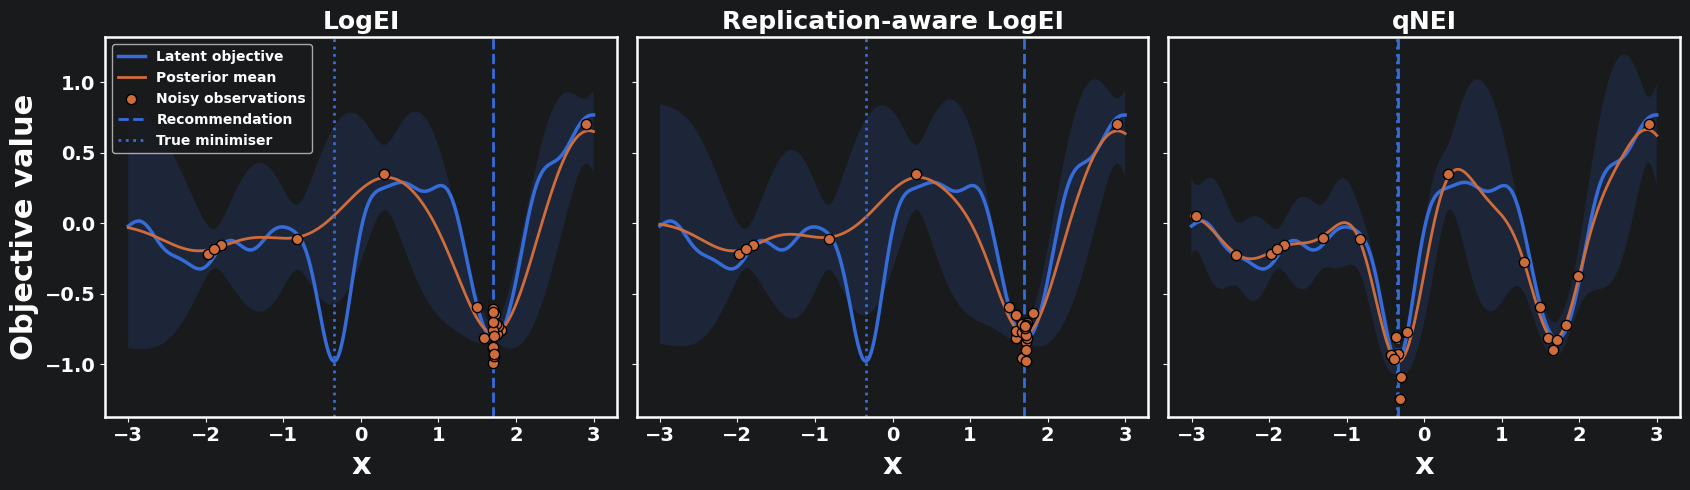

In [10]:
def final_summary(name, result):
    final_model = result["model_final"]
    x_rec, y_rec_latent, std_rec = current_recommendation_from_model(final_model, grid_X)

    train_X = result["train_X_final"]
    train_Y = result["train_Y_final"]

    return {
        "method": name,
        "n_total_observations": train_X.shape[0],
        "n_unique_x": n_unique_1d(train_X),
        "best_noisy_observed": float(torch.min(train_Y)),
        "best_latent_sampled": float(torch.min(latent_objective(train_X))),
        "recommended_x": float(x_rec),
        "recommended_latent_value": float(y_rec_latent),
        "recommendation_std": float(std_rec),
        "recommendation_regret": float(y_rec_latent - true_best_y),
    }


summary_df = pd.DataFrame([
    final_summary("LogEI", logei_result),
    final_summary("Replication-aware LogEI", replication_result),
    final_summary("qNEI", qnei_result),
])

display(summary_df)

results = {
    "LogEI": logei_result,
    "Replication-aware LogEI": replication_result,
    "qNEI": qnei_result,
}

fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)

for ax, (name, result) in zip(axes, results.items()):
    train_X = result["train_X_final"]
    train_Y = result["train_Y_final"]
    model = result["model_final"]

    mean_original, std = posterior_on_grid_original_scale(model, grid_X)

    ax.plot(grid_X.view(-1), grid_Y_true.view(-1), linewidth=2.5, label="Latent objective")
    ax.plot(grid_X.view(-1), mean_original.view(-1), linewidth=2.0, label="Posterior mean")
    ax.fill_between(
        grid_X.view(-1).detach().cpu().numpy(),
        (mean_original - 2 * std).view(-1).detach().cpu().numpy(),
        (mean_original + 2 * std).view(-1).detach().cpu().numpy(),
        alpha=0.15,
    )

    ax.scatter(
        train_X.view(-1),
        train_Y.view(-1),
        s=55,
        edgecolor="black",
        linewidth=1.0,
        zorder=3,
        label="Noisy observations"
    )

    x_rec, y_rec_latent, _ = current_recommendation_from_model(model, grid_X)
    ax.axvline(float(x_rec), linestyle="--", linewidth=2.0, label="Recommendation")
    ax.axvline(float(true_best_x), linestyle=":", linewidth=2.0, label="True minimiser")

    ax.set_title(name, fontsize=18, fontweight="bold")
    ax.set_xlabel("x", fontsize=22, fontweight="bold")
    style_ax(ax)

axes[0].set_ylabel("Objective value", fontsize=22, fontweight="bold")
axes[0].legend(prop={"size": 10, "weight": "bold"})
plt.tight_layout()
plt.show()

## 10. Noisy best value versus model-based recommendation

This diagnostic compares two different ways of tracking optimisation progress during a noisy BO run.

The left panel tracks the **best noisy observation so far**.
The right panel tracks the **true latent value at the model's current recommendation**.

These are not the same quantity, and the difference between them is central to the interpretation of noisy BO.

---

### Best noisy observation can be over-optimistic

In a noiseless optimisation problem, the best observed value is usually a reliable record of progress.

If the observed value improves, then the actual objective value at that point has improved as well.

In this notebook, however, the optimiser observes

$$
y = f(x) + \varepsilon,
$$

not the true latent value $f(x)$.

For a minimisation problem, favourable noise means a negative noise contribution. A point can therefore appear much lower than it truly is.

This is why the left panel can fall **below the true minimum line**.

That does not mean the optimiser has found a point better than the true global minimum. It means the noisy measurement is overly optimistic.

In the figure, this is especially clear for qNEI: its best noisy observation eventually becomes substantially lower than the true latent minimum. That value is not physically a better optimum; it is a noisy observation that happened to undershoot the latent function.

So the left panel answers:

> what is the best value we have measured?

not:

> what is the best true objective value we have found?

---

### Why the best noisy curve only moves downward

The left panel is a running-best diagnostic.

At each BO step, it stores the lowest noisy observation seen so far. Therefore, each curve can only stay the same or move downward.

Once a very low noisy value has been observed, it remains the best noisy observation even if all later measurements are worse.

This makes the curve look like steady optimisation progress, but in a noisy setting part of that apparent progress may simply be favourable measurement noise.

---

### Why the model recommendation behaves differently

The right panel shows the true latent value at the point currently recommended by the final GP posterior at each step.

This is not a running best value.

At every step, the GP is refit after receiving new data. The posterior mean can shift, and the model's recommended minimiser can move from one region of the search space to another.

Because of this, the recommendation curve can move downward or upward.

A downward jump means the model has moved its recommendation toward a better latent region. An upward jump means the model has revised its belief and moved toward a worse latent region.

In this figure, qNEI shows a sharp downward jump around the middle of the BO run. This indicates that qNEI has moved its model-based recommendation into the true global-minimum basin. After that, its recommended latent value stays close to the true minimum line.

By contrast, LogEI and replication-aware LogEI remain near a higher latent value. They have found a good local region, but their model recommendations do not move into the true global basin in this single run.

---

### How to read the two panels together

The left panel can make qNEI look extremely strong because its best noisy observation becomes much lower than the true minimum. But this is partly an artefact of noise.

The right panel gives a more meaningful diagnostic of the model's actual recommendation quality.

Here, qNEI is still the strongest method, but for a better reason: its recommendation moves close to the true global minimum, rather than merely recording an unusually low noisy measurement.

This distinction is important.

A method should not be judged only by the lowest noisy value it has measured. In noisy BO, a better question is:

> after accounting for noise and posterior uncertainty, which point does the model recommend?

---

### Key takeaway

The best noisy observation can be over-optimistic because it may include favourable measurement noise.

The model-based recommendation can move up or down because the GP posterior is updated after each new observation.

In this run, qNEI not only obtains a very low noisy observation, but also shifts its model-based recommendation into the true global-minimum region. That is the stronger evidence that qNEI is behaving better in this noisy optimisation problem.

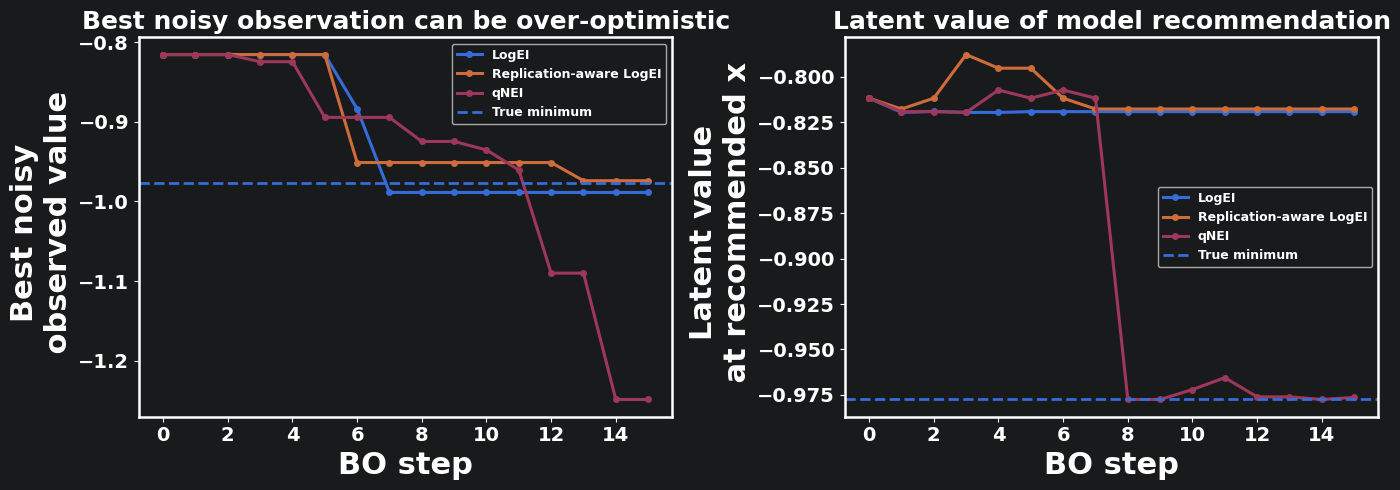

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, result in results.items():
    hist = result["history"]

    steps = [h["step"] for h in hist]
    best_noisy = [h["best_noisy_observed"] for h in hist]
    rec_latent = [h["recommendation_latent_y"] for h in hist]

    axes[0].plot(steps, best_noisy, "-o", linewidth=2.2, markersize=4, label=f"{name}")
    axes[1].plot(steps, rec_latent, "-o", linewidth=2.2, markersize=4, label=name)

axes[0].axhline(float(true_best_y), linestyle="--", linewidth=2.0, label="True minimum")
axes[1].axhline(float(true_best_y), linestyle="--", linewidth=2.0, label="True minimum")

axes[0].set_title("Best noisy observation can be over-optimistic", fontsize=18, fontweight="bold")
axes[0].set_xlabel("BO step", fontsize=22, fontweight="bold")
axes[0].set_ylabel("Best noisy \n observed value", fontsize=22, fontweight="bold")

axes[1].set_title("Latent value of model recommendation", fontsize=18, fontweight="bold")
axes[1].set_xlabel("BO step", fontsize=22, fontweight="bold")
axes[1].set_ylabel("Latent value \n at recommended x", fontsize=22, fontweight="bold")

for ax in axes:
    ax.legend(prop={"size": 9, "weight": "bold"})
    style_ax(ax)

plt.tight_layout()
plt.show()

## 11. Exploration, replication, and recommendation uncertainty

This diagnostic looks at how the three BO workflows use their evaluation budget over time.

The left panel tracks the number of **unique evaluated locations**. The right panel tracks the posterior standard deviation at the model's current recommendation.

Together, these plots show two different aspects of noisy BO behaviour:

- how much of the budget is spent exploring new locations,
- and how uncertain the model remains about its recommended point.

---

### Unique evaluated locations

The left panel shows a clear difference between the methods.

LogEI and qNEI both increase almost linearly in the number of unique evaluated locations. This means that, in this run, they spend essentially every BO step evaluating a new point.

Their curves nearly overlap because both methods evaluate the same number of unique locations at each step. The small horizontal offset in the code is only used to make both lines visible. It does not change the underlying values.

Replication-aware LogEI behaves differently.

Its curve has flatter regions where the number of unique locations does not increase as quickly. These correspond to repeated measurements at previously evaluated points.

This is exactly the intended behaviour of the replication-aware workflow: it sacrifices some exploration in order to confirm promising but uncertain locations.

So the left panel makes the exploration-replication trade-off visible:

> ordinary LogEI and qNEI mainly explore new locations, while replication-aware LogEI spends part of the same budget on confirmation.

---

### Uncertainty at the recommended point

The right panel tracks the posterior standard deviation at the model's current recommendation.

For LogEI and replication-aware LogEI, this uncertainty decreases fairly smoothly over the run. This means that their recommended points become increasingly well-characterised by the model.

Replication-aware LogEI is especially interpretable here: because it sometimes repeats promising points, it can reduce uncertainty around the region it is currently focused on.

qNEI shows a different pattern.

Its recommendation uncertainty initially decreases, then increases sharply around the point where the model moves into the true global-minimum basin, and then decreases again afterwards.

This jump is not necessarily bad.

It means the model has shifted its recommendation into a different region of the search space. When the recommendation moves to a newly identified basin, the posterior uncertainty at that recommended point can temporarily increase because the model has less local confirmation there.

In other words, higher recommendation uncertainty can sometimes reflect useful exploration rather than worse modelling.

---

### How to interpret these plots together

The two panels show that uncertainty reduction and global optimisation are not always the same objective.

Replication-aware LogEI reduces uncertainty by spending evaluations on confirmation, but this also leaves fewer evaluations for exploring new regions.

qNEI explores more aggressively and, in this run, moves into the true global-minimum basin. However, that move temporarily increases uncertainty at the recommended point because the recommendation shifts into a less-confirmed region.

So a lower posterior standard deviation is not automatically better.

It depends on whether the model is becoming certain about the right region.

---

### Key takeaway

This figure shows that the three methods use the same evaluation budget in different ways.

LogEI and qNEI mostly spend their budget on new locations. Replication-aware LogEI deliberately spends some evaluations on repeated measurements, producing fewer unique locations.

At the same time, qNEI's temporary rise in recommendation uncertainty reflects a change in the recommended basin, not simply a failure to learn.

The important lesson is that noisy BO should be judged by both exploration behaviour and recommendation quality, not by uncertainty reduction alone.

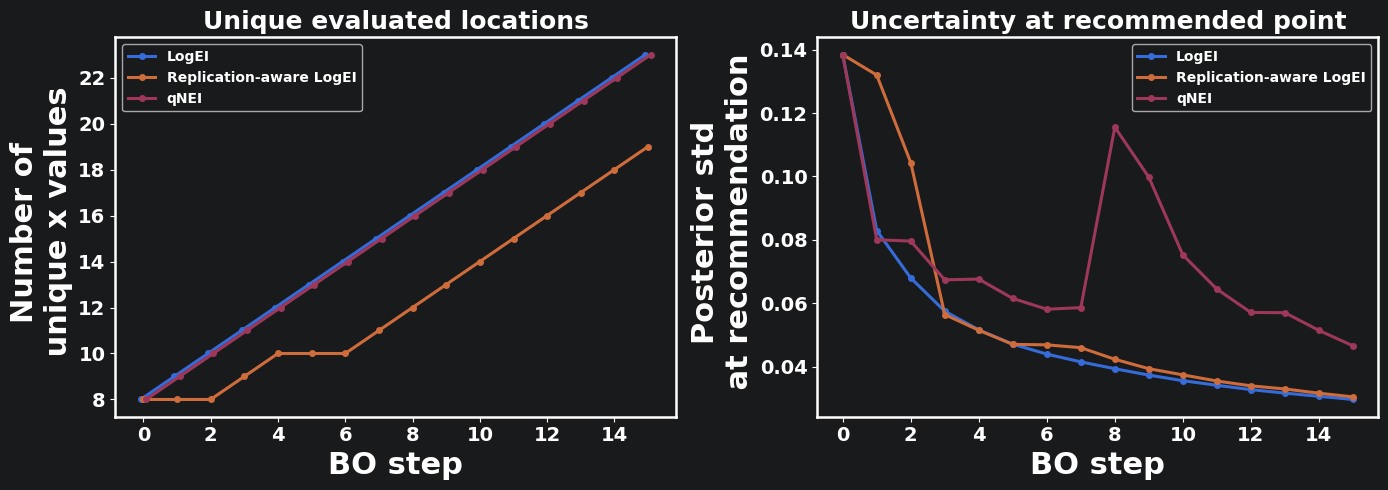

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

step_offsets = {
    "LogEI": -0.08,
    "Replication-aware LogEI": 0.00,
    "qNEI": 0.08,
}

for name, result in results.items():
    hist = result["history"]
    steps = np.array([h["step"] for h in hist], dtype=float)
    n_unique = [h["n_unique"] for h in hist]
    rec_std = [h["recommendation_std"] for h in hist]

    axes[0].plot(
        steps + step_offsets[name],
        n_unique,
        "-o",
        linewidth=2.2,
        markersize=4,
        label=name,
    )

    axes[1].plot(
        steps,
        rec_std,
        "-o",
        linewidth=2.2,
        markersize=4,
        label=name,
    )

axes[0].set_title("Unique evaluated locations", fontsize=18, fontweight="bold")
axes[0].set_xlabel("BO step", fontsize=22, fontweight="bold")
axes[0].set_ylabel("Number of \n unique x values", fontsize=22, fontweight="bold")

axes[1].set_title("Uncertainty at recommended point", fontsize=18, fontweight="bold")
axes[1].set_xlabel("BO step", fontsize=22, fontweight="bold")
axes[1].set_ylabel("Posterior std \n at recommendation", fontsize=22, fontweight="bold")

for ax in axes:
    ax.legend(prop={"size": 10, "weight": "bold"})
    style_ax(ax)

plt.tight_layout()
plt.show()

## 12. Repeating the comparison across multiple random trials

So far, the comparison has focused on one BO run starting from one initial noisy dataset.

That single run is useful because it lets us inspect the behaviour of each method in detail. However, noisy BO is stochastic: the result can depend on the initial Sobol points, the sampled observation noise, and the random optimisation details inside the acquisition function.

So we now repeat the comparison across multiple random trials.

---

### Why multiple trials are needed

A single BO run can be informative, but it should not be treated as definitive.

In noisy optimisation, a method may look especially good or bad in one run because:

- the initial points happened to be favourable,
- an early noisy observation happened to be unusually low,
- the acquisition optimiser found a different local optimum,
- or the method happened to explore a more useful region by chance.

Repeating the experiment across several seeds gives a more stable view of method behaviour.

The goal is not to produce a large statistical benchmark, but to check whether the patterns seen in the single-run analysis are reasonably robust.

---

### What `run_one_trial(...)` does

The function `run_one_trial(...)` performs one complete comparison between the three methods.

For a given trial seed, it first creates a fresh initial dataset:

- new Sobol initial points,
- new noisy observations,
- and the same known observation noise level.

Then it runs the three BO workflows from that same initial dataset:

- LogEI,
- replication-aware LogEI,
- and qNEI.

This makes the comparison within each trial fair, because all three methods start from the same information.

---

### Why different seeds are used inside one trial

Inside each trial, the seed is reset before running each method:

- `seed_trial + 100` for LogEI,
- `seed_trial + 200` for replication-aware LogEI,
- `seed_trial + 300` for qNEI.

This separates the randomness used by the different methods while keeping the overall trial reproducible.

The purpose is to avoid one method accidentally inheriting randomness from the previous method's run.

---

### What is stored for each trial

After each method finishes, `final_summary(...)` extracts the final diagnostics.

Each row stores quantities such as:

- the final recommendation,
- the recommendation regret,
- the number of unique evaluated locations,
- and the posterior uncertainty at the recommendation.

The trial seed is also stored, so each row can be traced back to the run that produced it.

All rows are collected into `multi_df`.

---

### What the grouped summary shows

The table `summary_multi` then groups the results by method and computes average behaviour across the 10 trials.

For each method, it reports:

- mean and standard deviation of the recommended latent value,
- mean and standard deviation of the final recommendation regret,
- mean number of unique evaluated locations,
- and mean posterior uncertainty at the recommendation.

This gives a higher-level view of how the methods behave on average, rather than relying only on the single illustrative run.

---

### Key takeaway

This cell turns the comparison from a single example into a small repeated experiment.

The purpose is to ask whether the qualitative conclusions from the single run still make sense across multiple random initialisations and noisy observations.

In particular, it helps us compare not only which method can perform well in one run, but also how stable each method is across repeated noisy BO campaigns.

---

In [13]:
def run_one_trial(seed_trial, n_steps=10):
    set_seed(seed_trial)

    train_X = draw_sobol_samples(bounds=bounds, n=1, q=n_init).squeeze(0)
    train_Y = observe_noisy(train_X, noise_std=noise_std)

    set_seed(seed_trial + 100)
    logei = run_logei_noisy_bo_loop(
        train_X_init=train_X,
        train_Y_init=train_Y,
        n_steps=n_steps,
        noise_std=noise_std,
        num_restarts=8,
        raw_samples=96,
    )

    set_seed(seed_trial + 200)
    rep = run_replication_aware_logei_bo_loop(
        train_X_init=train_X,
        train_Y_init=train_Y,
        n_steps=n_steps,
        noise_std=noise_std,
        replicate_threshold=0.10,
        min_repeats_at_best=3,
        max_repeats_per_point=5,
        num_restarts=8,
        raw_samples=96,
    )

    set_seed(seed_trial + 300)
    qnei = run_qnei_noisy_bo_loop(
        train_X_init=train_X,
        train_Y_init=train_Y,
        n_steps=n_steps,
        noise_std=noise_std,
        num_restarts=8,
        raw_samples=96,
        sampler_samples=96,
    )

    rows = []
    for name, result in {
        "LogEI": logei,
        "Replication-aware LogEI": rep,
        "qNEI": qnei,
    }.items():
        row = final_summary(name, result)
        row["trial_seed"] = seed_trial
        rows.append(row)

    return rows


trial_seeds = list(range(10))
all_rows = []

for s in trial_seeds:
    all_rows.extend(run_one_trial(seed_trial=s, n_steps=10))

multi_df = pd.DataFrame(all_rows)

summary_multi = (
    multi_df
    .groupby("method")
    .agg(
        mean_recommendation_latent_value=("recommended_latent_value", "mean"),
        std_recommendation_latent_value=("recommended_latent_value", "std"),
        mean_regret=("recommendation_regret", "mean"),
        std_regret=("recommendation_regret", "std"),
        mean_unique_x=("n_unique_x", "mean"),
        mean_recommendation_std=("recommendation_std", "mean"),
    )
    .reset_index()
)

display(summary_multi)

,method,mean_recommendation_latent_value,std_recommendation_latent_value,mean_regret,std_regret,mean_unique_x,mean_recommendation_std
0,LogEI,-0.811228,0.244706,0.166247,0.244706,17.8,0.042842
1,Replication-aware LogEI,-0.906826,0.076555,0.070649,0.076555,12.6,0.053648
2,qNEI,-0.853596,0.204985,0.123879,0.204985,18.0,0.064406


## 13. Multi-trial comparison of final regret and exploration behaviour

After repeating the noisy BO comparison across multiple random trials, we now visualise the distribution of outcomes.

This figure summarises two quantities:

- the final recommendation regret,
- and the number of unique evaluated locations.

Together, these show both optimisation performance and budget allocation behaviour.

---

### Final recommendation regret

The left panel compares the final recommendation regret for the three methods.

For this minimisation problem, regret is defined as

$$
\text{regret} = f(x_{\text{rec}}) - f(x^*),
$$

where $x_{\text{rec}}$ is the point recommended by the final model and $x^*$ is the true global minimiser.

A lower regret means that the model's final recommendation is closer to the true optimum.

In this plot, all three methods can sometimes achieve very low regret, meaning that each method is capable of recommending a point close to the true minimum in some trials.

However, the distributions are different.

LogEI shows a relatively wide spread, meaning that its final recommendation quality varies substantially across trials.

Replication-aware LogEI and qNEI have lower median regret in this set of runs, suggesting that they more often produce better final recommendations under this noisy setting.

However, the boxplots also show overlap between the methods, so this should not be interpreted as a universal ranking. It is a small repeated experiment, not a definitive benchmark.

---

### Exploration versus replication

The right panel shows the number of unique evaluated locations.

This is where the behavioural difference is clearest.

LogEI and qNEI both evaluate almost all steps at new locations, so their number of unique evaluated points stays close to the maximum possible value.

Replication-aware LogEI evaluates fewer unique locations because it deliberately spends part of its budget on repeated measurements.

This confirms that the replication-aware workflow is genuinely doing something different: it is not simply another version of LogEI, but a policy that trades some exploration for confirmation.

---

### How to interpret the two panels together

The key point is that better noisy BO behaviour is not only about finding the lowest final regret.

It is also about how the evaluation budget is used.

LogEI and qNEI are mostly exploration-driven in this setup. They spend nearly all evaluations on new locations.

Replication-aware LogEI is more conservative. It gives up some unique evaluations in order to confirm promising points under noise.

In these runs, replication-aware LogEI achieves competitive regret while using fewer unique locations. That suggests that confirmation can sometimes stabilise the final recommendation, even though it reduces exploration.

qNEI also performs competitively while still exploring broadly, reflecting its more principled treatment of noisy improvement.

---

### Key takeaway

This multi-trial comparison supports the main message of the tutorial.

Noisy BO should not be judged only by the best noisy observation from a single run.

A more useful comparison asks:

> how good is the final model recommendation, and how was the evaluation budget spent?

In this set of trials, qNEI and replication-aware LogEI both improve the noisy BO story in different ways:

- qNEI handles noisy improvement through posterior uncertainty over the incumbent,
- replication-aware LogEI explicitly spends evaluations on confirming promising points.

These are two different responses to the same problem: noisy observations make it difficult to know which low-looking points should be trusted.

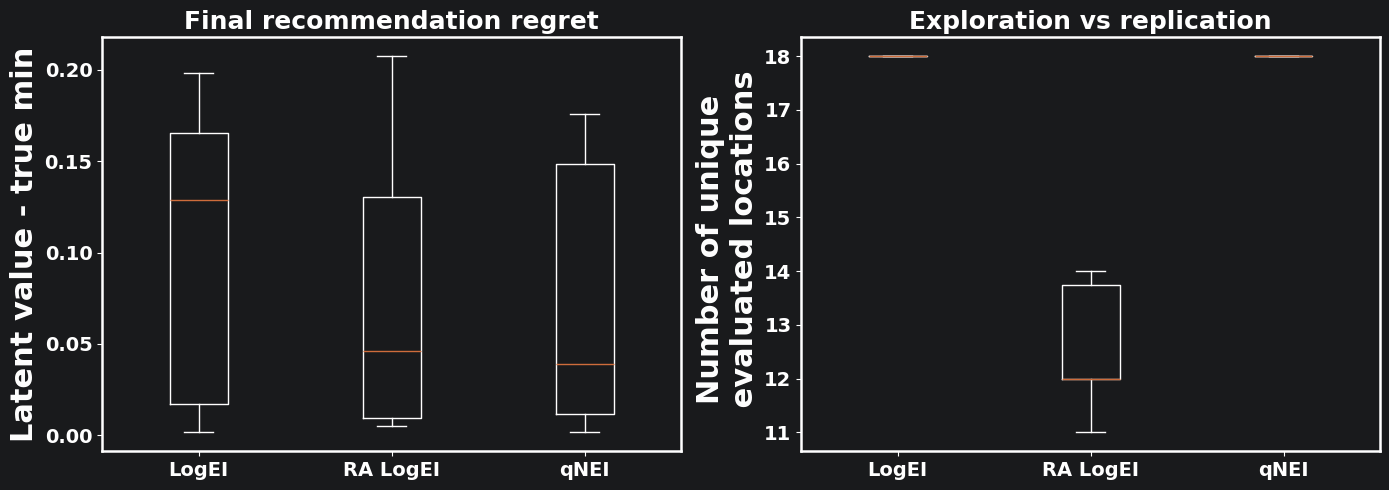

In [14]:
methods = ["LogEI", "Replication-aware LogEI", "qNEI"]

regret_data = [
    multi_df.loc[multi_df["method"] == m, "recommendation_regret"].values
    for m in methods
]

unique_data = [
    multi_df.loc[multi_df["method"] == m, "n_unique_x"].values
    for m in methods
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(regret_data, tick_labels=["LogEI", "RA LogEI", "qNEI"], showfliers=False)
axes[0].set_title("Final recommendation regret", fontsize=18, fontweight="bold")
axes[0].set_ylabel("Latent value - true min", fontsize=22, fontweight="bold")
axes[0].tick_params(axis="x")

axes[1].boxplot(unique_data, tick_labels=["LogEI", "RA LogEI", "qNEI"], showfliers=False)
axes[1].set_title("Exploration vs replication", fontsize=18, fontweight="bold")
axes[1].set_ylabel("Number of unique \n evaluated locations", fontsize=22, fontweight="bold")
axes[1].tick_params(axis="x")

for ax in axes:
    style_ax(ax)

plt.tight_layout()
plt.show()

## 🧭 Closing Remarks

In this tutorial, we moved from **workflow-aware Bayesian Optimisation under cost and decision constraints** to the problem of running BO when the observations themselves are **noisy and uncertain**.

The central idea was that once an evaluation no longer reveals the true latent objective value exactly, the optimisation problem changes in an important way.

The challenge is no longer only:

- how to fit a surrogate,
- how to define an acquisition function,
- and how to repeat the BO loop,

but also:

- how to distinguish the latent objective from the noisy measurement,
- how to avoid over-trusting the best observed value,
- how to decide whether a promising point should be repeated,
- and how to compare BO policies when apparent improvement may partly be measurement noise.

That shift was the whole point of the notebook.

In the earlier BO tutorials, an evaluation was usually treated as if it returned the objective value itself.

Here, the optimiser observed

$$
y = f(x) + \varepsilon,
$$

rather than $f(x)$ directly.

That single change had consequences throughout the workflow.

It meant that the best noisy observation could be misleading. It meant that the GP should be told about observation noise. It meant that the incumbent value used by an improvement-based acquisition function needed to be handled carefully. And it meant that repeated measurements could become meaningful rather than redundant.

So the main conceptual move in this tutorial was from asking:

> **where does the objective look lowest?**

to asking:

> **which low-looking observations should we trust, and how should uncertainty affect the next experiment?**

That is much closer to realistic experimental optimisation.

---

Structurally, the BO loop still followed the same general pattern:

1. fit a Gaussian Process surrogate to the currently observed data,
2. build an acquisition rule from that surrogate,
3. propose the next candidate,
4. evaluate the objective with noisy observations,
5. update the dataset,
6. and repeat.

But the meaning of a “good next candidate” changed.

In a noiseless setting, a good candidate is usually one that is expected to improve the objective.

In the noisy setting, that is no longer enough.

A candidate also has to be interpreted in terms of:

- whether its apparent value may be noise-driven,
- whether the current best point is actually reliable,
- whether it is better to explore a new location,
- or whether it is worth repeating a promising existing condition.

That is why this tutorial introduced three distinct noisy BO workflows:

- **LogEI**,
- **replication-aware LogEI**,
- and **qNEI**.

All three workflows used the same synthetic noisy minimisation problem, the same noise-aware GP setup, the same final recommendation rule, and the same diagnostic framework.

But they differed in how they treated noisy improvement and uncertainty.

That made the comparison meaningful.

---

The **standard LogEI** workflow served as the natural baseline.

It used a familiar improvement-based acquisition function and proposed a new point at every BO step.

Because the problem was framed as minimisation, the GP was fit to the transformed target $-y$, allowing BoTorch's maximisation convention to be used without changing the original interpretation of the objective.

The notebook also avoided using the raw best noisy observation directly as the LogEI incumbent.

Instead, it used a **model-based incumbent**: the best posterior mean among the already observed points on the BO scale.

That was a more stable choice under noise, because the raw lowest observation may simply be a lucky downward fluctuation.

So standard LogEI represented a reasonable improvement-based baseline.

But it still depended on a single incumbent value.

In the single run, LogEI found a strong local minimum, but its final model recommendation remained in the wrong basin rather than moving to the true global minimum.

That result should not be interpreted as a universal failure of LogEI.

But it showed a real risk:

> under noisy observations, a fixed-incumbent improvement rule can become over-committed to a local region that looks promising early on.

---

The **replication-aware LogEI** workflow then added a practical experimental decision layer.

It kept the same underlying LogEI acquisition logic, but introduced an explicit choice at each step:

- propose a new LogEI candidate,
- or repeat a currently promising but uncertain point.

This was the notebook's most direct representation of replication as an experimental strategy.

The point was not that replication-aware LogEI is mathematically optimal.

It is a heuristic.

But it captures a realistic laboratory question:

> if this condition looks good, should we trust it immediately, or should we measure it again?

The results showed the trade-off clearly.

Replication-aware LogEI used the same total number of observations as the other methods, but spent some of them on repeated measurements. It therefore produced fewer unique evaluated locations, because part of the budget was spent on confirmation rather than exploration.

This helped characterise the local region it focused on, but in the single run it did not move the search into the true global-minimum basin.

So the lesson was not that replication automatically improves optimisation.

The better lesson was:

> replication changes the information-gathering strategy by trading exploration for confidence.

That trade-off can be valuable, but it can also reduce the number of new regions explored.

---

The **qNEI** workflow then introduced a more principled noisy-improvement strategy.

Unlike ordinary EI or LogEI, qNEI does not rely on treating the current best value as a fixed known quantity.

Instead, it accounts for uncertainty in the latent function values at the already evaluated baseline points.

For a maximisation problem, the key idea is that qNEI estimates an improvement of the form

$$
\operatorname{qNEI}(X)
= \mathbb{E}\left[
\max\left(
\max f(X) - \max f(X_{\text{baseline}}), 0
\right)
\right].
$$

The expectation is taken over the joint GP posterior.

In this notebook, because the original task was minimisation, qNEI operated on the transformed function

$$
g(x) = -f(x).
$$

So improvement in $g(x)$ corresponded to reduction in the original objective $f(x)$.

This was the most important mathematical distinction in the tutorial.

qNEI compares candidates against a posterior distribution over what the current best latent value might be, rather than against a single fixed incumbent value.

That is exactly why qNEI is well suited to noisy BO.

In the single run, qNEI was the only method that moved into the true global-minimum basin. Its best noisy observation became extremely low, but the more important result was not the noisy value itself. The stronger evidence was that its **model-based recommendation** also moved close to the true global minimum.

A low noisy observation alone can be misleading.

A model recommendation near the true minimum is a more meaningful sign that the method has learned the right region.

---

The diagnostics made these workflow differences concrete.

The final posterior comparison showed that:

- **LogEI** identified a strong local region but did not move into the true global basin in the single run,
- **replication-aware LogEI** confirmed promising locations but explored fewer unique points,
- and **qNEI** found the true global-minimum region in this example.

The best-noisy-value plot then exposed the danger of using noisy observations directly.

For a minimisation problem, the best noisy observation can fall below the true latent minimum.

That does not mean the optimiser has found something better than the global optimum.

It means the observation was pushed downward by favourable noise.

So one of the most important lessons of the notebook was:

> the best noisy observation is not the same thing as the best latent objective value.

That is why the model-based recommendation plot was so important.

It showed not just what value had been measured, but what point the model currently believed to be best after accounting for all the data.

In that diagnostic, qNEI's recommendation moved sharply into the global-minimum basin and then stayed close to the true minimum.

That was stronger evidence of successful noisy optimisation than the best noisy observation alone.

---

The unique-location and uncertainty plots then showed the exploration-replication trade-off directly.

LogEI and qNEI evaluated almost every BO step at a new location.

Replication-aware LogEI evaluated fewer unique locations because some of its budget was used for repeated measurements.

That difference was not a bug.

It was the design of the method.

The uncertainty-at-recommendation plot also showed why uncertainty reduction must be interpreted carefully.

A lower posterior standard deviation is not automatically better.

It matters whether the model is becoming certain about the right region.

qNEI temporarily showed higher uncertainty when its recommendation moved into the global-minimum basin. That was not necessarily a failure. It reflected the fact that the model had shifted to a more promising but less-confirmed region.

So another important lesson was:

> in noisy BO, uncertainty should be interpreted together with recommendation quality and exploration behaviour.

---

Finally, the multi-trial comparison helped move beyond a single illustrative run.

Because noisy BO is stochastic, performance can vary depending on the initial Sobol design, the sampled observation noise, the acquisition optimiser, and the regions discovered early in the run.

The boxplots compared final recommendation regret and the number of unique evaluated locations across multiple seeds.

This made the main pattern clearer.

LogEI and qNEI mostly spent their budgets on new locations.

Replication-aware LogEI consistently evaluated fewer unique locations, confirming that it was genuinely behaving as a replication-aware policy.

The regret distributions also showed that replication-aware LogEI and qNEI could both produce competitive final recommendations, but through different mechanisms.

qNEI handled noisy improvement by integrating over posterior uncertainty in the incumbent.

Replication-aware LogEI handled noisy uncertainty by explicitly repeating promising points.

Those are two different responses to the same problem.

---

So by the end of this tutorial, we have not replaced the BO framework with something entirely new.

Instead, we have adapted the same BO structure to a more realistic observation model:

- one in which evaluations are noisy,
- one in which the best observed value may be misleading,
- one in which repeated measurements can be meaningful,
- and one in which acquisition functions must reason about uncertainty in the current best latent value.

That gives us a natural stopping point:

> we now know how to build, run, and interpret noisy BO workflows in which improvement, uncertainty, and replication all matter at the same time.

Looking forward, this also gives a natural bridge to the rest of **Part 6**.

If this tutorial asked what happens when one objective is observed noisily, the next tutorials can ask what happens when the optimisation problem becomes even richer:

- when there are multiple competing objectives,
- when evaluations can occur at different fidelities,
- when the search space is structured or combinatorial,
- or when experimental decisions must account for context as well as candidate choice.

Those extensions all build on the same idea introduced here.

Real BO is not only about maximising an acquisition function.

It is about making decisions under uncertainty.

So the main takeaway of this tutorial is:

> once observations are noisy, BO should not be judged only by the best value it has measured, but by how well it turns uncertain measurements into reliable model-based recommendations.